[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/storopoli/ciencia-de-dados/main?filepath=notebooks%2FAula_18_b__Redes_Neurais_com_PyTorch.ipynb)
<br>
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/storopoli/ciencia-de-dados/blob/main/notebooks/Aula_18_b_Redes_Neurais_com_PyTorch.ipynb)

# Redes Neurais com PyTorch

**Objetivos**: Aprender Redes Neurais Artificiais (RNA) usando a biblioteca `PyTorch`.

## PyTorch

[**PyTorch**](https://www.pytorch.org/) é uma biblioteca de código aberto para aprendizado de máquina aplicável a uma ampla variedade de tarefas. Foi criada pelo **Facebook** em 2016 é a principal biblioteca para criação e treinamento de redes neurais artificiais. A API toda é escrita em Python mas é executada em C++ na CPU ou em CUDA/ROCM na GPU.

No momento que eu escrevo esse tutorial (Abril de 2021), PyTorch está superando o TensorFlow (Google) em desempenho e adoção de uso. Isso acontece tanto na [academia](http://horace.io/pytorch-vs-tensorflow/) (mensurado pela adoção de artigos científicos nos principais encontros científicos de Aprendizagem Profunda e Aprendizagem de Máquina) quanto na [indústria](https://www.infoworld.com/article/3597904/why-enterprises-are-turning-from-tensorflow-to-pytorch.html) (mensurado pela adoção de grandes e renomadas empresas de tecnologia).

### Atualização (Junho 2022):

TensorFlow está morto, Vida Longa ao PyTorch: [Google lost the battle for machine learning to Meta, insiders say. Now it's betting the future of its own products on a new internal AI project.](https://www.businessinsider.com/facebook-pytorch-beat-google-tensorflow-jax-meta-ai-2022-6).

> Now, under the shadow of PyTorch, Google has been quietly building out a machine learning framework, called JAX (at one point an acronym for "Just After eXecution," but officially no longer stands for anything), that many see as the successor to TensorFlow.

Meus comentários: JAX é mais um backend de _autodiff_ do que uma biblioteca de redes neurais.
Ou seja tem um uso muito mais amplo que PyTorch.
Por exemplo, como um amostrador Monte Carlo de correntes ou cadeias Markov (_Markov Chain Monte Carlo_ - MCMC).

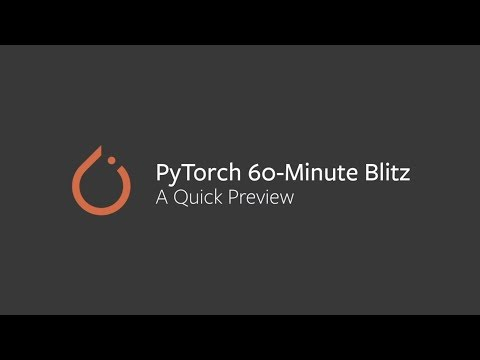

In [2]:
from IPython.display import YouTubeVideo

YouTubeVideo('u7x8RXwLKcA', width=600, height=400)

## O que é uma Rede Neural Artificial?

Redes neurais artificiais (RNAs) são modelos computacionais inspirados pelo sistema nervoso central (em particular o cérebro) que são capazes de realizar o aprendizado de máquina bem como o reconhecimento de padrões. Redes neurais artificiais geralmente são apresentadas como sistemas de "neurônios interconectados, que podem computar valores de entradas", simulando o comportamento de redes neurais biológicas.

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/redes_neurais.jpeg?raw=1" alt="redes neurais" style="width: 500px;"/>

## Como a rede neural aprende?

Em cada neurônio há uma função de ativação (*activation function*) que processa uma combinação linear entre inputs e pesos sinápticos, gerando assim um sinal de saída.

A informação flui da *input layer* para as *hidden layers* e por fim para a *output layer*. Nesse fluxo os inputs de dados da *input layer* são alimentados para os neurônios das *hidden layers* que por fim alimentam o neurônio final da *output layer*.

A primeira passada de informação (propagação) pela rede é geralmente feita com parâmetros aleatórios para as funções de ativação dos neurônios.

Ao realizar a propagação, chamada de *feed forward*, temos sinais de saídas nos neurônios da output layer.

No fim da propagação, a função custo (uma métrica de erro) é calculada e o modelo então ajusta os parâmetros dos neurônios na direção de um menor custo (por meio do gradiente - derivada multivariada).

Assim uma nova propagação é gerada e a numa nova função custo e calculada. Assim como é realizado a atualização dos parâmetros dos neurônios.

O nome desse algoritmo é **Retro-propagação** (*Backpropagation*). E cada vez que ele é executado denomina-se como época (*epoch*). E quandos as épocas estabelecidas se encerram, a rede neural encerra o seu treinamento/aprendizagem.

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/backpropagation.gif?raw=1" alt="backpropagation" style="width: 500px;"/>

## Funções de Ativação

| **Sigmoid**                                                  | **Tanh**                                                     | **ReLU**                                                     | **Leaky ReLU**                                               |
| ------------------------------------------------------------ | ------------------------------------------------------------ | ------------------------------------------------------------ | ------------------------------------------------------------ |
| $g(z)=\frac{1}{1+e^{-z}}$                                    | $g(z)=\frac{e^{z}-e^{-z}}{e^{z}+e^{-z}}$                     | $g(z)=\max (0, z)$                                           | $\begin{array}{c}{g(z)=\max (\epsilon z, z)} \\ {\text { com } \epsilon \ll 1}\end{array}$ |
| ![Illustration](https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/sigmoid.png?raw=1) | ![Illustration](https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/tanh.png?raw=1) | ![Illustration](https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/relu.png?raw=1) | ![Illustration](https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/leaky-relu.png?raw=1) |



### Estruturação dos módulos de PyTorch

```python
import torch
```
* [`torch.Tensor`](https://pytorch.org/docs/stable/tensors.html) - Tensores (arrays N-D)
* [`torch.nn`](https://pytorch.org/docs/stable/nn.html) - Redes Neurais (_**N**eural **N**etworks_)
* [`torch.optim`](https://pytorch.org/docs/stable/optim.html) - Otimização (_**Optim**ization_)
* [`torch.data`](https://pytorch.org/docs/stable/data.html) - *Datasets* e Ferramentas de Streaming de Dados
* [`torch.autograd`](https://pytorch.org/docs/stable/autograd.html) - Diferenciação Automática (_**Auto**matic Differentiation_)
* [`torch.vision`](https://pytorch.org/docs/stable/torchvision/index.html) - Ferramentas de Manipulação de Imagens e Visão Computacional
* [`torch.audio`](https://pytorch.org/audio/stable/index.html) - Ferramentas de Manipulação de Áudio
* [`torch.jit`](https://pytorch.org/docs/stable/jit.html) - Compilação _**j**ust-**i**n-**t**ime_ de modelos PyTorch em binários


### `torch.Tensor`

* `NumPy` - `np.ndarray`
* `pandas` - `pd.Series` e `pd.DataFrame`
* `PyTorch` - `torch.Tensor`

## Algoritmos de Otimização

PyTorch possui diversos:
* **SGD**: _**S**tochastic **G**radient **D**escent_
* **SGD com Momento**: SGD com Momento usando a derivada (ou gradiente) do ponto atual
* **SGD com Momento Nesterov**: SGD com Momento mas  usa a derivada (ou o gradiente) parcial do ponto seguinte (Nesterov, 1983)
* **RMSprop**: SGD com taxa de aprendizagem adaptativa  (Hinton, Srivastava & Swersky, 2012) - `RMSProp`
* **AdaGrad**: SGD com taxa de aprendizagem adaptativa (Duchi, Hazan, & Yoram, 2011) -  `AdaGrad`
* **Adam**: SGD com taxa de aprendizagem adaptativa e momento (Kingma, Diederick & Jimmy, 2014) - `ADAM`

Os mais importantes são o SGD e o Adam

### SGD - Stochastic Gradient Descent

[`torch.optim.sgd()`](https://pytorch.org/docs/stable/_modules/torch/optim/sgd.html):

* `lr` - Taxa de Aprendizagem $\eta > 0$
* `momentum=0.0` - hyperparâmetro $\geq 0$ que acelera o *gradient descent* na direção relevante e mitiga oscilações.
* `nesterov=False` - `bool` para se aplica *Nesterov Momentum* ou não. *Nesterov Momentum* usa posições intermediárias do gradiente no cálculo do *momentum*. Proposto por Yuri Nesterov em 1983.
    

### Momentum

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/momentum.gif?raw=1" alt="momentum" style="width: 300px;"/>

### Adam

Adam é um método de SGD que usa uma estimativa adaptativa dos momentos de primeira ordem e momentos de segunda ordem. Proposto por Kingma & Ba (2014).

[`torch.optim.Adam()`](https://pytorch.org/docs/stable/_modules/torch/optim/adam.html):

* `lr=0.001` - Taxa de Aprendizagem $\eta > 0$
* `betas=(0.9, 0.999)` - Uma tupla de valores:
    1. `betas[0]` - decréscimo exponencial da estimativa dos momentos de primeira ordem
    2. `betas[1]` - decréscimo exponencial da estimativa dos momentos de segunda ordem

### Momentum

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/comparacao_otimizadores.gif?raw=1" alt="comparacao_otimizadores" style="width: 500px;"/>

### Momentum

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/opt1.gif?raw=1" alt="comparacao_otimizadores_2" style="width: 500px;"/>

### Momentum

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/opt2.gif?raw=1" alt="comparacao_otimizadores_3" style="width: 500px;"/>

## Funções Custo

As funções custos se dividem em dois tipos:

1. Funções Custo de **Classificação**
2. Funções Custo de **Regressão**

### Funcões Custo de Classificação

Mais utilizadas


* *Binary Cross-entropy* (Entropia cruzada binária): [`torch.nn.BCELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
* *Categorical Cross-entropy - Negative Log-Likelihood Loss* (Entropia cruzada categórica): [`torch.nn.NLLLoss()`](https://pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html)

### Funcões Custo de Regressão

Mais utilizadas
* MSE - *Mean Squared Error* (Erro quadrado médio): [`torch.nn.MSELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)
* MAE - *Mean Absolute Error - $\| . \|_1$* (Erro absoluto médio): [`torch.nn.L1Loss()`](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html#torch.nn.L1Loss)

## Como construir sua rede neural no PyTorch

Construir redes neurais com o **PyTorch** é tão fácil quanto com **Keras**.

Temos que criar uma Rede Neural a partir de uma classe [`nn.Module()`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html?highlight=module#torch.nn.Module) e criar um construtor com o método `__init__()` e implementar todas as layers e propagações desejadas com o método `forward()`.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [4]:
class Model(nn.Module):
    # Construtor
    def __init__(self):  # Chamado de dunder methods __init__
        super(Model, self).__init__()
        self.fc1 = nn.Linear(4, 4) # primeira hidden layer
        self.fc2 = nn.Linear(4, 1) # segunda hidden layer

    # Propagação (Feed Forward)
    def forward(self, x):
        x = F.relu(self.fc1(x)) # poderia colocar F.leaky_relu
        x = F.relu(self.fc2(x))
        return x


# Instancia o Model()
model = Model()

print(model)

Model(
  (fc1): Linear(in_features=4, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=1, bias=True)
)


### Exemplo de Classificação Binária

In [5]:
class ClassBin(nn.Module):
    # Construtor
    def __init__(self):
        super(ClassBin, self).__init__()
        self.fc1 = nn.Linear(20, 20) # primeira hidden layer
        self.fc2 = nn.Linear(20, 1) # segunda hidden layer
        self.sigmoid = nn.Sigmoid() # output layer com ativação Sigmoid

    # Propagação (Feed Forward)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.sigmoid(x)
        return x

model = ClassBin()

print(model)

ClassBin(
  (fc1): Linear(in_features=20, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


### Exemplo de Regressão

In [6]:
class Reg(nn.Module):
    # Construtor
    def __init__(self):
        super(Reg, self).__init__()
        self.fc1 = nn.Linear(20, 20) # primeira hidden layer
        self.fc2 = nn.Linear(20, 1) # segunda hidden layer output 1 único neurônio

    # Propagação (Feed Forward)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return x

model = Reg()

print(model)

Reg(
  (fc1): Linear(in_features=20, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=1, bias=True)
)


### Exemplo de Multiclassificação (não-binária - acima de duas classes)

In [7]:
class MultiClass(nn.Module):
    # Construtor
    def __init__(self):
        super(MultiClass, self).__init__()
        self.fc1 = nn.Linear(20, 20)  # primeira hidden layer
        self.fc2 = nn.Linear(20, 10)  # segunda hidden layer
        self.softmax = nn.Softmax(10) # output layer com ativação ativação softmax com 10 classes

    # Propagação (Feed Forward)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.softmax(x)
        return x

model = MultiClass()

print(model)

MultiClass(
  (fc1): Linear(in_features=20, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=10, bias=True)
  (softmax): Softmax(dim=10)
)


## Como treinar sua rede neural no PyTorch

Uma vez especificado e instanciado o modelo, podemos manipulá-lo de maneira dinâmica. Não é preciso "compilar" que nem o TensorFlow/Keras. Escolhemos a função custo (`loss_fn`) como `nn.NLLLoss()` e também a taxa de aprendizagem $\eta$ em `1e-6` e a quantidade de épocas a serem treinadas (`epochs`):

```python
model = Sua_rede_neural()
loss_fn = nn.NLLLoss()
learning_rate = 1e-6
epochs = 100

# Instânciar o Otimizador SGD
optimizer = torch.optim.sgd(model.parameters(), lr=learning_rate)

for t in range(epochs):
    model.train() # Colocar o modelo em modo de treinamento (calcula os gradientes)
    
    # Propagação (Feed Forward)
    y_pred = model(X_train)
    
    # Calcular erro usando a função-custo
    loss = loss_fn(y_pred, y_train)
    print(t, loss.item())

    # Zera os gradientes antes da Retro-propagação (Backpropagation)
    model.zero_grad()

    # Retro-propagação (Backpropagation)
    loss.backward()

    # Atualização dos parâmetros
    optimizer.step()
```

## Como ajustar o treinamento sua rede neural no PyTorch

* Batch Size
* Dropout

### Batch Size

Tamanho do Batch de dados que passa por vez pela rede neural antes da atualização dos parâmetros pelo *backpropagation*. Tamanhos grandes resultam em instabilidade no treinamento. Geralmente usam-se potências de $2$ $(2,4,8,16,\dots, 2^n)$.

Em Abril de 2018, Yann LeCun, um dos principais pesquisadores sobre redes neurais e ganhador do "nobel" da computação (Prêmio Turing) [twittou](https://twitter.com/ylecun/status/989610208497360896) em resposta à Masters & Luschi (2018) que mostrava diversos contextos de *batch size*:

>"Friends don't let friends use mini-batches larger than 32"

Então 32 é um valor empiricamente verificado que dá estabilidade ao treinamento.

> Dominic Masters and Carlo Luschi. "Revisiting small batch training for deep neural networks." _arXiv preprint arXiv:1804.07612_ (2018).

Para controlar como que os dados são inseridos no modelo e, logo, o Batch Size é preciso implementar um [`torch.utils.data.DataLoader()`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader):

```python
import torch
from torch.utils.data import TorchDataset, DataLoader

# Converter X e y para torch.Tensor
X = torch.Tensor(X)
y = torch.Tensor(y)

# Um Dataset de Tensores - Array [X, y]
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)
```

Argumentos do `DataLoader()`:

* **`dataset`**: um `Dataset` PyTorch
    * tem [vários tipos](https://pytorch.org/docs/stable/data.html)
    * no nosso exemplo vou usar um simples [`TensorDataset`](https://pytorch.org/docs/stable/_modules/torch/utils/data/dataset.html#TensorDataset) que é um wrapper de `np.ndarray` e `pd.Series` para `torch.Tensor`)
* **batch_size**: `int` - tamanho do Batch Size, padrão é 1
* **shuffle**: `bool` - se vai embaralhar os dados antes de enviar em batches ao modelo, padrão é `False`. Recomendo usar `shuffle=True`

### Dropout

Uma medida de regularização na qual evita-se overfitting proposta por Hinton em 2012. *Dropout* é um algoritmo que especifica que a cada iteração de época do treino os neurônios possuem uma probabilidade de serem removidos (não utilizados) para a aprendizagem. Geralmente a probabilidade ideal fica em torno de 20% ($0.2$).

Coloca-se como se fosse uma camada após a camada que deseja aplicar o dropout:

```python
model = torch.nn.Sequential(
    nn.Linear(4, 4) ,  # hidden layer
    nn.Dropout(0.2)    # dropout layer
)
```

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/dropout.gif?raw=1" alt="dropout" style="width: 500px;"/>

## Exemplo com o dataset Titanic

Contém 891 passageiros reais do Titanic que afundou em 15/04/1912 matando 1502 de 2224 passageiros e tripulação que estavam a bordo.

* `survived`: *dummy* `0` ou `1`
* `pclass`: Classe do Passageiro
    - `1`: Primeira Classe
    - `2`: Segunda Classe
    - `3`: Terceira Classe
* `sex`: Sexo `male` ou `female`
* `age`: Idade
* `sibsp`: Número de Irmãos (*Siblings*) e Esposas (*spouse*) a bordo
* `parch`: Número de pais/filhos a bordo
* `fare`: Valor pago pela passagem em libras
* `embarked`: Porto que embarcou
    - `C`: Cherbourg
    - `Q`: Queenstown
    - `S`: Southampton)
* `class`: Mesmo que `pclass` só que em texto
* `adult_male`: *dummy* para `age > 16` e `sex == 'male'`
* `deck`: Qual deck a cabine do passageiro se situava
* `alive`: Mesmo que survived só que com `yes` ou `no`
* `alone`: *dummy* para se viajava sozinho

>Obs: usar `random_state = 123`

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/titanic.png?raw=1" alt="titanic" style="width: 500px;"/>

In [8]:
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
titanic = sns.load_dataset('titanic')

feature_names = ['pclass', 'female', 'age', 'fare']
titanic['female'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic.dropna(subset=feature_names, inplace=True)  #891 para 714

X = titanic[feature_names].to_numpy()
y = titanic['survived'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=123)

In [9]:
print('Tamanho de X_train: ', X_train.shape)
print('Tamanho de X_test: ', X_test.shape)
print('Tamanho de y_train: ', y_train.shape)
print('Tamanho de y_test: ', y_test.shape)

Tamanho de X_train:  (535, 4)
Tamanho de X_test:  (179, 4)
Tamanho de y_train:  (535,)
Tamanho de y_test:  (179,)


In [10]:
class ClassBin(nn.Module):
    # Construtor
    def __init__(self):
        super(ClassBin, self).__init__()
        self.linear1 = nn.Linear(4, 4)    # primeira hidden layer
        self.dropout1 = nn.Dropout(0.2)   # dropout layer
        self.linear2 = nn.Linear(4, 4)    # segunda hidden layer
        self.dropout2 = nn.Dropout(0.2)   # dropout layer
        self.linear3 = nn.Linear(4, 1)    # terceira hidden layer
        self.dropout3 = nn.Dropout(0.2)   # dropout layer
        self.sigmoid = nn.Sigmoid()

    # Propagação (Feed Forward)
    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = self.dropout1(x)
        x = F.relu(self.linear2(x))
        x = self.dropout2(x)
        x = F.relu(self.linear3(x))
        x = self.dropout3(x)
        x = self.sigmoid(x)
        return x

model = ClassBin()
print(model)

ClassBin(
  (linear1): Linear(in_features=4, out_features=4, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (linear2): Linear(in_features=4, out_features=4, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (linear3): Linear(in_features=4, out_features=1, bias=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (sigmoid): Sigmoid()
)


In [11]:
loss_fn = nn.BCELoss()
epochs = 100
batch_size = 32  # X_train 535 / 32 = 16.71 (então são 17 batches de 32)
learning_rate = 0.1

# Instânciar o Otimizador Adam
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [12]:
from torch.utils.data import TensorDataset, DataLoader

# Converter X e y para torch.Tensor
X_train = torch.Tensor(X_train)
y_train = torch.Tensor(y_train)
X_test = torch.Tensor(X_test)
y_test = torch.Tensor(y_test)

# Um Dataset de Tensores - Array [X, y]
train = TensorDataset(X_train, y_train)
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)

test = TensorDataset(X_test, y_test)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=True)

In [13]:
for t in range(epochs):
    model.train() # Colocar o modelo em modo de treinamento (calcula os gradientes)

    # Batch Size
    for data in train_loader:
        # dar nome aos bois
        X = data[0]
        y = data[1]

        # Propagação (Feed Forward)
        y_pred = model(X)

        # Calcular erro usando a função-custo
        # y precisa virar um Tensor com tamanho (batch_size, 1)
        loss = loss_fn(y_pred, y.unsqueeze_(1))

        # Zera os gradientes antes da Retro-propagação (Backpropagation)
        model.zero_grad()

        # Retro-propagação (Backpropagation)
        loss.backward()

        # Atualização dos parâmetros
        optimizer.step()

    # Fim da Época
    print(f"""Época {t + 1},
          Custo Treino: {round(loss.item(), 3)}""")

Época 1,
          Custo Treino: 0.816
Época 2,
          Custo Treino: 0.693
Época 3,
          Custo Treino: 0.693
Época 4,
          Custo Treino: 0.693
Época 5,
          Custo Treino: 0.693
Época 6,
          Custo Treino: 0.693
Época 7,
          Custo Treino: 0.693
Época 8,
          Custo Treino: 0.693
Época 9,
          Custo Treino: 0.693
Época 10,
          Custo Treino: 0.693
Época 11,
          Custo Treino: 0.693
Época 12,
          Custo Treino: 0.693
Época 13,
          Custo Treino: 0.693
Época 14,
          Custo Treino: 0.693
Época 15,
          Custo Treino: 0.693
Época 16,
          Custo Treino: 0.693
Época 17,
          Custo Treino: 0.693
Época 18,
          Custo Treino: 0.693
Época 19,
          Custo Treino: 0.693
Época 20,
          Custo Treino: 0.693
Época 21,
          Custo Treino: 0.693
Época 22,
          Custo Treino: 0.693
Época 23,
          Custo Treino: 0.693
Época 24,
          Custo Treino: 0.693
Época 25,
          Custo Treino: 0.693
Época 26,

### Acurácia do Modelo

Usar o comando `model.eval()`

Para a métrica acurácia, retorna um score de acurácia `float` entre $0$ e $1$
    
> Obs: Regressão Logística acurácias: 0.69 Treino e 0.7 Teste

> Obs: *Support Vector Machines* acurácias: 0.79 Treino e 0.75 Teste

> Obs: Árvores de Decisão acurácias: 0.79 Treino e 0.79 Teste

> Obs: Florestas Aleatórias acurácias: 0.84 Treino e 0.82 Teste

In [14]:
model.eval() # coloca o modelo em modo de avaliação (sem calcular gradientes)

train_pred = model(X_train)
train_pred = train_pred.detach().apply_(lambda x : 1 if x > 0.5 else 0)
train_acc = torch.sum(train_pred.flatten() == y_train) / train_pred.size(0)

test_pred = model(X_test)
test_pred = test_pred.detach().apply_(lambda x : 1 if x > 0.5 else 0)
test_acc = torch.sum(test_pred.flatten() == y_test) / test_pred.size(0)

print(f"Acurácia de Treino: {train_acc}")
print('\n ---------------------------\n')
print(f"Acurácia de Teste: {test_acc}")

Acurácia de Treino: 0.590654194355011

 ---------------------------

Acurácia de Teste: 0.6033519506454468


---
## Exercicios
---

1. Com base no material apresentado no notebook, o que é uma função de
ativação, como a ReLU? Por que normalmente usamos funções de ativação entre as
camadas?

A função de ativação processa a combinação linear entres os dados de entrada e os pesos. A ReLu filtra os valores, se for negativo ela retorna zero e se for positivo ela retorna o proprio numero. As funções de ativação são usadas entre as camadas para introduzir não-linearidade no modelo, isso permite que a rede modele relações mais complexas e resolva problemas com XOR.

2. Explique o que cada uma das seguintes linhas de código faz e por que ela é
necessária:

*   model.train()
*   optimizer.step()

Além disso, explique qual é a diferença fundamental entre os modos model.train() e model.eval()?

A model.train() serve para colocar a rede neural em modo de treinamento, ela é fundamental pois ativia comportamentos exclusivos da etapa de treino.

O optimizer.step() é responsavel pela atualização dos parametros, esse processo é fundamental para o aprendizado da rede, permitindo o ajuste de pesos e vieses com o intuito de minimizar o erro.

A maior diferença entre model.train() e model.eval() é o comportamento internos de suas camadas. O train() usa probabilidade para desligar alguns neuronios com o Dropout. Ja o eval() muda o comportamento de certas camadas, onde o Dropout para de funcionar e permite o uso de toda os dados para avaliação.

3. Modifique a classe ClassBin para que a rede tenha a seguinte arquitetura:
* Camada de entrada: mantém as 4 features de entrada
* Primeira camada oculta: nn.Linear com 4 neurônios de entrada e 16
neurônios de saída, seguida por ativação ReLU
* Segunda camada oculta: nn.Linear com 16 neurônios de entrada e 8
neurônios de saída, seguida por ativação ReLU
* Camada de saída: nn.Linear com 8 neurônios de entrada e 1 neurônio de
saída, seguida por ativação Sigmoid
* Remova todas as camadas de Dropout da nova arquitetura

Depois:
* Treine o novo modelo com os mesmos hiperparâmetros do modelo original
* Compare a acurácia final de treino e teste com a do modelo original

In [26]:
class ClassBinNova(nn.Module):
    # construtor
    def __init__(self):
        super(ClassBinNova, self).__init__()
        self.linear1 = nn.Linear(4, 16)
        self.linear2 = nn.Linear(16, 8)
        self.linear3 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    # propagação
    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        x = self.sigmoid(self.linear3(x))
        return x

model_novo = ClassBinNova()
print(model_novo)

ClassBinNova(
  (linear1): Linear(in_features=4, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=8, bias=True)
  (linear3): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [27]:
loss_fn = nn.BCELoss()
epochs = 100
batch_size = 32
learning_rate = 0.1
optimizer_ex3 = torch.optim.Adam(model_novo.parameters(), lr=learning_rate)

# treinamento
for t in range(epochs):
    model_novo.train()

    for data in train_loader:
        X = data[0]
        y = data[1]

        y_pred = model_novo(X)
        loss = loss_fn(y_pred, y.unsqueeze_(1))

        model_novo.zero_grad()
        loss.backward()
        optimizer_ex3.step()

        # Fim da Época
        print(f"""Época {t + 1},
              Custo Treino: {round(loss.item(), 3)}""")

Época 1,
              Custo Treino: 1.125
Época 1,
              Custo Treino: 0.62
Época 1,
              Custo Treino: 0.766
Época 1,
              Custo Treino: 1.506
Época 1,
              Custo Treino: 0.622
Época 1,
              Custo Treino: 0.979
Época 1,
              Custo Treino: 1.156
Época 1,
              Custo Treino: 0.69
Época 1,
              Custo Treino: 0.608
Época 1,
              Custo Treino: 0.648
Época 1,
              Custo Treino: 0.669
Época 1,
              Custo Treino: 0.631
Época 1,
              Custo Treino: 0.67
Época 1,
              Custo Treino: 0.635
Época 1,
              Custo Treino: 0.77
Época 1,
              Custo Treino: 0.65
Época 1,
              Custo Treino: 0.638
Época 2,
              Custo Treino: 0.672
Época 2,
              Custo Treino: 0.66
Época 2,
              Custo Treino: 0.661
Época 2,
              Custo Treino: 0.695
Época 2,
              Custo Treino: 0.621
Época 2,
              Custo Treino: 0.72
Época 2,
         

In [30]:
model_novo.eval()

train_pred = model_novo(X_train)
train_pred = train_pred.detach().apply_(lambda x : 1 if x > 0.5 else 0)
train_acc = torch.sum(train_pred.flatten() == y_train) / train_pred.size(0)

test_pred = model_novo(X_test)
test_pred = test_pred.detach().apply_(lambda x : 1 if x > 0.5 else 0)
test_acc = torch.sum(test_pred.flatten() == y_test) / test_pred.size(0)

print(f"Acurácia de Treino: {train_acc}")
print('\n ---------------------------\n')
print(f"Acurácia de Teste: {test_acc}")

Acurácia de Treino: 0.590654194355011

 ---------------------------

Acurácia de Teste: 0.6033519506454468


Como os dois modelos apresentaram exatamete a mesma acuraria, isso indica que ambos estão sofrendo com underfitting, ou seja, não aprenderam absolutamente nada. Se ao remover o dropout e as mudar os parametros o modelo continua apresentando o mesmo resultado, isso indica que o problema que causa o underfitting esta em outro lugar.

4. Usando o modelo original do notebook:
* Substitua o otimizador Adam por SGD
* Treine o modelo com o novo otimizador
* Observe o comportamento do custo (loss) durante o treinamento
* Compare a acurácia final com a obtida anteriormente

O SGD com essa taxa de aprendizado pareceu uma boa escolha?

In [34]:
model_sgd = ClassBin()
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.1)

# treinamento
for t in range(epochs):
    model_sgd.train()

    for data in train_loader:
        X = data[0]
        y = data[1]

        y_pred = model_sgd(X)
        loss = loss_fn(y_pred, y.unsqueeze_(1))

        model_sgd.zero_grad()
        loss.backward()
        optimizer_sgd.step()

    if t % 10 == 0:
        print(f"Época {t}, Custo (Loss): {round(loss.item(), 3)}")

model_sgd.eval()

Época 0, Custo (Loss): 0.692
Época 10, Custo (Loss): 0.687
Época 20, Custo (Loss): 0.693
Época 30, Custo (Loss): 0.671
Época 40, Custo (Loss): 0.644
Época 50, Custo (Loss): 0.685
Época 60, Custo (Loss): 0.701
Época 70, Custo (Loss): 0.677
Época 80, Custo (Loss): 0.68
Época 90, Custo (Loss): 0.708


ClassBin(
  (linear1): Linear(in_features=4, out_features=4, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (linear2): Linear(in_features=4, out_features=4, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (linear3): Linear(in_features=4, out_features=1, bias=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (sigmoid): Sigmoid()
)

In [35]:
model_sgd.eval()

train_pred = model_sgd(X_train)
train_pred = train_pred.detach().apply_(lambda x : 1 if x > 0.5 else 0)
train_acc = torch.sum(train_pred.flatten() == y_train) / train_pred.size(0)

test_pred = model_sgd(X_test)
test_pred = test_pred.detach().apply_(lambda x : 1 if x > 0.5 else 0)
test_acc = torch.sum(test_pred.flatten() == y_test) / test_pred.size(0)

print(f"Acurácia de Treino: {train_acc}")
print('\n ---------------------------\n')
print(f"Acurácia de Teste: {test_acc}")

Acurácia de Treino: 0.590654194355011

 ---------------------------

Acurácia de Teste: 0.6033519506454468


Ao rodar o SGD o Loss se manteve oscilando entre o valor de 0.69, essa observação somada com a acurácia que se manteve a mesma, mostra que o modelo continua apresentando um erro no processo de aprendizagem, portanto o uso do SGD com uma taxa de 0.1 não foi uma boa escolha.

5. Usando o modelo original e o otimizador Adam:
* No DataLoader, mude o batch_size de 32 para um valor muito maior, como
512
* Treine o modelo e observe a acurácia
* Depois, mude o batch_size para um valor bem pequeno, como 4, e treine

Como a mudança no batch_size afetou:
* a estabilidade do custo (loss) a cada época
* a acurácia final do modelo

In [39]:
train_loader_512 = DataLoader(train, batch_size=512, shuffle=True)
model_512 = ClassBin()
opt_512 = torch.optim.Adam(model_512.parameters(), lr=0.1)
loss_fn = nn.BCELoss()

for t in range(epochs):
    model_512.train()
    for data in train_loader_512:
        y_pred = model_512(data[0])
        loss = loss_fn(y_pred, data[1].unsqueeze_(1))
        model_512.zero_grad()
        loss.backward()
        opt_512.step()

model_512.eval()
train_pred_512 = model_512(X_train).detach().apply_(lambda x : 1 if x > 0.5 else 0)
acc_512 = torch.sum(train_pred_512.flatten() == y_train) / train_pred_512.size(0)
print(f"Acurácia Treino (Batch 512): {acc_512}")

Acurácia Treino (Batch 512): 0.590654194355011


In [40]:
train_loader_4 = DataLoader(train, batch_size=4, shuffle=True)
model_4 = ClassBin()
opt_4 = torch.optim.Adam(model_4.parameters(), lr=0.1)

for t in range(epochs):
    model_4.train()
    for data in train_loader_4:
        y_pred = model_4(data[0])
        loss = loss_fn(y_pred, data[1].unsqueeze_(1))
        model_4.zero_grad()
        loss.backward()
        opt_4.step()

model_4.eval()
train_pred_4 = model_4(X_train).detach().apply_(lambda x : 1 if x > 0.5 else 0)
acc_4 = torch.sum(train_pred_4.flatten() == y_train) / train_pred_4.size(0)
print(f"Acurácia Treino (Batch 4): {acc_4}")

Acurácia Treino (Batch 4): 0.590654194355011


Usando um Batch = 512 em um treino de 535 linhas, estamos permitindo que o modelo veja quase tudo de uma so vez. Isso faz com que o Loss oscile muito menos, criando uma estabilidade maior, mas as atualizações dos pesos são lentas. Ja com um Batch = 4 a rede atualiza os pesos o tempo todo, usando pouca informação, isso aumenta a oscilação do Loss, deixando o modelo desastabilizado. A Acurácia para ambos permanece a mesma.

### Observação final

Mesmo com todas as alterações feitas no código, a acurácia dos modelos se manteve a mesma. Isso indica que o problema é que a taxa de aprendizado está muito alta, isso faz com que o modelo chute a resposta para o valor predominante de pessoas que morreram, ou seja, o modelo não aprende absolutamente nada. Diminuir a taxa de aprendizado do Adam permite ver resultados diferentes de acurácia, mas para fins desse exercicio irei deixar a taxa original.

### Reflexões

1. Qual a importância da função de ativação em uma rede neural?

A função de ativação é fundamental para garantir a não-linearidade de uma rede neural, ela permite que o modelo desenhe curvas e aprenda padrões irregulares, isso resolve o problema que causou o primeiro grande inverso da IA.

2. Como a arquitetura da rede influencia o desempenho final?

Uma boa arquitetura é ideal para define a capacidade do modelo de enxergar padrões. Se ela for muito pequena causar underfitting, se for muito grande causa overfitting.

3. O que muda ao trocar o otimizador?

Mudar o otimizador altera as regras de passos do modelos. O SGD pode fazer com que o modelo fique preso "buracos" enquanto o Adam se adapta melhor o tamanho do passo de maneira dinamica.

4. Como o tamanho do batch pode afetar o treinamento?

Sim, o batch define a quantidade de informações que a rede analisa antes de atualizar seus pesos, isso impacta diretamente na qualidade do treinamento. Lotes grande como o de 512 criam uma visão mais clara do todo, porem com uma atualização mais lenta.

5. Em quais situações uma rede mais simples pode ser mais adequada do que
uma rede maior?

Tudo depende do tamanho e complexidade do problema que estamos trabalhando. Basicamente redes simples são mais eficientes para problemas simples, enquanto redes maiores são o ideal para trabalhar com como complexos como por exemplo, a analise de imagens médicas de alta resolução.

## Referências

* Hinton, Geoffrey, Nitish Srivastava, and Kevin Swersky. “Neural Networks for Machine Learning Lecture 6a Overview of Mini--Batch Gradient Descent,” 2012.
* Kingma, Diederik P., and Jimmy Ba. “Adam: A Method for Stochastic Optimization,” December 22, 2014. https://arxiv.org/abs/1412.6980.
* Nesterov, Y. A method of solving a convex programming problem with convergence rate O(1/sqr(k)). Soviet Mathematics Doklady, 27:372–376, 1983.
* Srivastava, Nitish, Geoffrey Hinton, Alex Krizhevsky, Ilya Sutskever, and Ruslan Salakhutdinov. “Dropout: A Simple Way to Prevent Neural Networks from Overfitting.” Journal of Machine Learning Research 15, no. 56 (2014): 1929–58.